# Week 2, Lecture 1: Python for ML — NumPy & Pandas Basics
## CS 2100/4700: Introduction to Machine Learning

**Duration:** 1 hour 15 minutes  
**Dataset:** UCI Adult Census Income (48,842 records)  

**Goals:**
- Master the fundamental tools for data manipulation in ML
- Load real data, explore it, and prepare it for ML

## Learning Objectives

By the end of this lecture, you will be able to:

1. Create and manipulate NumPy arrays
2. Perform vectorized operations (no loops!)
3. Create and navigate Pandas DataFrames
4. Select, filter, and transform data efficiently

# Unit I: NumPy Fundamentals

## 1.1 Why NumPy?

Python lists are slow for numerical computation. NumPy arrays are:
- **Fast** — implemented in C
- **Memory efficient** — contiguous memory blocks
- **Convenient** — vectorized operations (no loops needed)

In [1]:
import numpy as np

# Compare: Python list vs NumPy array
py_list = [1, 2, 3, 4, 5]
np_array = np.array([1, 2, 3, 4, 5])

# NumPy operations are cleaner and faster
print("np_array * 2 =", np_array * 2)
print("np_array + 10 =", np_array + 10)

np_array * 2 = [ 2  4  6  8 10]
np_array + 10 = [11 12 13 14 15]


## 1.2 Creating Arrays

In [2]:
import numpy as np

# From a list
ages = np.array([25, 38, 52, 41, 30])
print(f"Ages: {ages}")
print(f"Shape: {ages.shape}, Type: {ages.dtype}")

Ages: [25 38 52 41 30]
Shape: (5,), Type: int64


## 1.3 Common Array Creation Functions

In [3]:
# Zeros and ones
zeros = np.zeros(5)
ones = np.ones(3)
print(f"Zeros: {zeros}")
print(f"Ones: {ones}")

# Range of values
sequence = np.arange(0, 10, 2)
linear = np.linspace(0, 1, 5)
print(f"Arange: {sequence}")
print(f"Linspace: {linear}")

Zeros: [0. 0. 0. 0. 0.]
Ones: [1. 1. 1.]
Arange: [0 2 4 6 8]
Linspace: [0.   0.25 0.5  0.75 1.  ]


In [4]:
# Random values (common in ML for initialization)
#np.random.seed(42)  # For reproducibility
random_uniform = np.random.rand(5)              # 5 values in [0, 1)
random_normal = np.random.randn(5)              # 5 values from N(0,1)
random_integers = np.random.randint(18, 65, size=5)  # 5 ages

print(f"Uniform [0,1): {random_uniform.round(2)}")
print(f"Normal N(0,1): {random_normal.round(3)}")
print(f"Random integers 18-65: {random_integers}")

Uniform [0,1): [0.95 0.02 0.82 0.66 0.44]
Normal N(0,1): [ 1.808 -1.022  1.141  1.294  0.291]
Random integers 18-65: [19 27 55 51 45]


## 1.4 Array Indexing and Slicing

In [5]:
# Sample: hours worked per week for 8 people
hours = np.array([40, 50, 35, 60, 45, 38, 55, 42])

print(f"First element: {hours[0]}")
print(f"Last element: {hours[-1]}")
print(f"Elements 2,3,4: {hours[-3:]}")
print(f"Every other: {hours[::-1]}")

First element: 40
Last element: 42
Elements 2,3,4: [38 55 42]
Every other: [42 55 38 45 60 35 50 40]


## 1.5 Vectorized Operations (The Power of NumPy)

**Key Insight:** In NumPy, operations apply to entire arrays without loops.

In [6]:
hours = np.array([40, 50, 35, 60, 45])

# Arithmetic on entire array
overtime = hours - 40
print(f"Overtime: {overtime}")

# Boolean operations
is_fulltime = hours >= 40
print(f"Full-time: {is_fulltime}")

# Use boolean array to filter
fulltime_hours = hours[is_fulltime]
print(f"Full-time hours: {fulltime_hours}")

Overtime: [ 0 10 -5 20  5]
Full-time: [ True  True False  True  True]
Full-time hours: [40 50 60 45]


## 1.6 Aggregation Functions

In [7]:
hours = np.array([40, 50, 35, 60, 45, 38, 55, 42])

print(f"Sum:    {np.sum(hours)}")
print(f"Mean:   {np.mean(hours):.1f}")
print(f"Std:    {np.std(hours):.1f}")
print(f"Min:    {np.min(hours)}")
print(f"Max:    {np.max(hours)}")
print(f"Median: {np.median(hours)}")

Sum:    365
Mean:   45.6
Std:    8.1
Min:    35
Max:    60
Median: 43.5


## 1.7 2D Arrays (Matrices)

In ML, data is typically a 2D array: rows = samples, columns = features.

In [8]:
# 3 people, 4 features each: [age, education_years, hours, capital_gain]
data = np.array([
    [39, 13, 40, 2174],
    [50, 13, 13, 0],
    [38, 9, 40, 0]
])

print(f"Shape: {data.shape}")
print(f"First row: {data[0]}")
print(f"First column (all ages): {data[:, 0]}")
print(f"Element [1,2]: {data[1, 2]}")

Shape: (3, 4)
First row: [  39   13   40 2174]
First column (all ages): [39 50 38]
Element [1,2]: 13


## Practice: NumPy

Complete the code below:

In [13]:
# Given this array of ages from census data:
ages = np.array([39, 50, 38, 53, 28, 37, 49, 52, 31, 42])

# TODO: Calculate mean age
mean_age = np.mean(ages)

# TODO: Find ages over 40
over_40 = ages[ages >= 40]

# TODO: Count how many are over 40
count_over_40 = np.sum(ages>40)
print(over_40.shape)

print(f"Mean age: {mean_age:.1f}")
print(f"Ages over 40: {over_40}")
print(f"Count over 40: {count_over_40}")

(5,)
Mean age: 41.9
Ages over 40: [50 53 49 52 42]
Count over 40: 5


<details>
<summary>Click for Solution</summary>

```python
mean_age = np.mean(ages)
over_40 = ages[ages > 40]
count_over_40 = len(over_40)  # or np.sum(ages > 40)
```
</details>

# Part II: Pandas Fundamentals

## 2.1 Why Pandas?

NumPy is great for numbers, but real datasets have:
- **Column names** (not just indices)
- **Mixed data types** (numbers, text, dates)
- **Missing values** that need handling

Pandas solves all of these.

In [14]:
import pandas as pd

# A DataFrame is like a spreadsheet
data = {
    'age': [39, 50, 38],
    'education': ['Bachelors', 'Bachelors', 'HS-grad'],
    'hours_per_week': [40, 13, 40],
    'income': ['>50K', '<=50K', '<=50K']
}
df = pd.DataFrame(data)
print(df)

   age  education  hours_per_week income
0   39  Bachelors              40   >50K
1   50  Bachelors              13  <=50K
2   38    HS-grad              40  <=50K


## 2.2 Creating DataFrames

In [15]:
import pandas as pd
import numpy as np

# Method 1: From dictionary (most common)
df = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Carol'],
    'age': [25, 30, 35],
    'salary': [50000, 60000, 70000]
})
print("From dictionary:")
print(df)

# Method 2: From NumPy array (add column names)
arr = np.array([[25, 50000], [30, 60000], [35, 70000]])
df2 = pd.DataFrame(arr)
print("\nFrom NumPy array:")
print(df2)

From dictionary:
    name  age  salary
0  Alice   25   50000
1    Bob   30   60000
2  Carol   35   70000

From NumPy array:
    0      1
0  25  50000
1  30  60000
2  35  70000


## 2.3 Basic DataFrame Inspection

These are the first commands you run on any new dataset:

In [16]:
# Create a sample DataFrame
df = pd.DataFrame({
    'age': [39, 50, 38, 53, 28],
    'education': ['Bachelors', 'Bachelors', 'HS-grad', 'Doctorate', 'Some-college'],
    'hours': [40, 13, 40, 45, 50]
})

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 3 rows:\n{df.head(3)}")

Shape: (5, 3)

Columns: Index(['age', 'education', 'hours'], dtype='str')

Data types:
age          int64
education      str
hours        int64
dtype: object

First 3 rows:
   age  education  hours
0   39  Bachelors     40
1   50  Bachelors     13
2   38    HS-grad     40


## 2.4 Selecting Columns

In [17]:
# Sample DataFrame
df = pd.DataFrame({
    'age': [39, 50, 38, 53],
    'education': ['Bachelors', 'Bachelors', 'HS-grad', 'Doctorate'],
    'hours': [40, 13, 40, 45]
})

# Single column → returns Series
ages = df['age']
print(f"Single column type: {type(ages).__name__}")
print(ages)

# Multiple columns → returns DataFrame
subset = df[['age', 'hours']]
print(f"\nMultiple columns type: {type(subset).__name__}")
print(subset)

Single column type: Series
0    39
1    50
2    38
3    53
Name: age, dtype: int64

Multiple columns type: DataFrame
   age  hours
0   39     40
1   50     13
2   38     40
3   53     45


## 2.5 Selecting Rows with loc and iloc

In [18]:
df = pd.DataFrame({
    'age': [39, 50, 38, 53],
    'education': ['Bachelors', 'Bachelors', 'HS-grad', 'Doctorate'],
    'hours': [40, 13, 40, 45]
})

# iloc: Integer-based indexing (like NumPy)
print("iloc[0] - First row:")
print(df.iloc[0])

print("\niloc[0:2] - First two rows:")
print(df.iloc[0:2])

# loc: Label-based indexing
print(f"\nloc[0, 'age']: {df.loc[0, 'age']}")
print("\nloc[0:2, ['age', 'hours']]:")
print(df.loc[0:2, ['age', 'hours']])

iloc[0] - First row:
age                 39
education    Bachelors
hours               40
Name: 0, dtype: object

iloc[0:2] - First two rows:
   age  education  hours
0   39  Bachelors     40
1   50  Bachelors     13

loc[0, 'age']: 39

loc[0:2, ['age', 'hours']]:
   age  hours
0   39     40
1   50     13
2   38     40


## 2.6 Filtering Rows with Conditions

This is how you subset data based on criteria — essential for EDA!

In [19]:
df = pd.DataFrame({
    'age': [39, 50, 38, 53, 28],
    'hours': [40, 13, 40, 45, 50],
    'income': ['>50K', '<=50K', '<=50K', '>50K', '<=50K']
})

# Filter: age over 40
older = df[df['age'] > 40]
print("Age over 40:")
print(older)

# Filter: high earners
high_income = df[df['income'] == '>50K']
print("\nHigh earners:")
print(high_income)

Age over 40:
   age  hours income
1   50     13  <=50K
3   53     45   >50K

High earners:
   age  hours income
0   39     40   >50K
3   53     45   >50K


In [20]:
# Multiple conditions (use & for AND, | for OR)
older_fulltime = df[(df['age'] > 40) & (df['hours'] >= 40)]
print("Age > 40 AND hours >= 40:")
print(older_fulltime)

Age > 40 AND hours >= 40:
   age  hours income
3   53     45   >50K


## 2.7 Adding and Modifying Columns

In [21]:
df = pd.DataFrame({
    'age': [39, 50, 38, 53],
    'hours': [40, 13, 40, 45]
})

# Add new column
df['overtime'] = df['hours'] - 40

df['age_group'] = df['age'].apply(lambda x: 'Senior' if x >= 50 else 'Adult')

print(df)

   age  hours  overtime age_group
0   39     40         0     Adult
1   50     13       -27    Senior
2   38     40         0     Adult
3   53     45         5    Senior


## 2.8 Basic Statistics with Pandas

In [22]:
df = pd.DataFrame({
    'age': [39, 50, 38, 53, 28, 37, 49],
    'hours': [40, 13, 40, 45, 50, 38, 55]
})

# Quick statistics for all numeric columns
print("describe():")
print(df.describe())

# Statistics for single column
print(f"\nMean age: {df['age'].mean():.1f}")
print(f"Median hours: {df['hours'].median()}")
print(f"Std of age: {df['age'].std():.2f}")

describe():
             age      hours
count   7.000000   7.000000
mean   42.000000  40.142857
std     8.944272  13.434143
min    28.000000  13.000000
25%    37.500000  39.000000
50%    39.000000  40.000000
75%    49.500000  47.500000
max    53.000000  55.000000

Mean age: 42.0
Median hours: 40.0
Std of age: 8.94


## 2.9 Value Counts (Frequency Tables)

Essential for understanding categorical variables:

In [23]:
df = pd.DataFrame({
    'education': ['Bachelors', 'HS-grad', 'Bachelors', 'Masters',
                  'HS-grad', 'HS-grad', 'Doctorate', 'Bachelors'],
    'income': ['>50K', '<=50K', '>50K', '>50K',
               '<=50K', '<=50K', '>50K', '<=50K']
})

# Count occurrences
print("Education counts:")
print(df['education'].value_counts())

# As percentages
print("\nIncome percentages:")
print(df['income'].value_counts(normalize=True))

Education counts:
education
Bachelors    3
HS-grad      3
Masters      1
Doctorate    1
Name: count, dtype: int64

Income percentages:
income
>50K     0.5
<=50K    0.5
Name: proportion, dtype: float64


## Practice: Pandas

Complete the code below:

In [ ]:
# Create this DataFrame
df = pd.DataFrame({
    'age': [39, 50, 38, 53, 28, 37, 49, 52],
    'workclass': ['Private', 'Self-emp', 'Private', 'Private',
                  'Private', 'State-gov', 'Private', 'Self-emp'],
    'hours': [40, 13, 40, 45, 50, 38, 55, 42],
    'income': ['>50K', '<=50K', '<=50K', '>50K',
               '<=50K', '<=50K', '>50K', '>50K']
})

# TODO: How many rows and columns?
print(f"Shape: {df._____}")

# TODO: Select only 'age' and 'income' columns
subset = df[_____]
print(f"\nSubset:\n{subset.head()}")

# TODO: Filter for people working over 40 hours
hardworkers = df[_____]
print(f"\nHard workers:\n{hardworkers}")

# TODO: Count income categories
income_counts = df['income']._____
print(f"\nIncome counts:\n{income_counts}")

<details>
<summary>Click for Solution</summary>

```python
print(f"Shape: {df.shape}")
subset = df[['age', 'income']]
hardworkers = df[df['hours'] > 40]
income_counts = df['income'].value_counts()
```
</details>

# Unit III: Loading the Dataset

Now we apply NumPy and Pandas to a real dataset. The **Adult Census Income** dataset from UCI contains census data used to predict whether a person earns over $50K/year.

| Attribute | Description |
|-----------|-------------|
| **Samples** | 48,842 records |
| **Features** | 14 (6 numeric, 8 categorical) |
| **Target** | Income: `>50K` or `<=50K` |
| **Source** | 1994 US Census |

## 3.1 Download the Dataset

The UCI Adult dataset is available online. We'll load it directly:

In [24]:
import pandas as pd
import numpy as np

# Dataset URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Column names (not included in the file)
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
           'marital_status', 'occupation', 'relationship', 'race',
           'sex', 'capital_gain', 'capital_loss', 'hours_per_week',
           'native_country', 'income']

# Load data
df = pd.read_csv(url, names=columns,  na_values='?', skipinitialspace=True)
print(f"Loaded {len(df)} records")

Loaded 32561 records


In [25]:
df.to_csv('adult_data.csv', index=False)

In [26]:
df.head(10)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


## 3.2 Understanding read_csv Parameters

```python
# Common parameters you'll use:
df = pd.read_csv(
    'data.csv',              # File path or URL
    names=columns,           # Column names (if not in file)
    na_values=' ?',          # Treat ' ?' as missing
    skipinitialspace=True,   # Remove leading spaces
    sep=',',                 # Delimiter (default is comma)
    header=0                 # Row number with column names
)
```

## 3.3 Loading Local Files

For your assignments, you'll typically load local files:

```python
# From current directory
df = pd.read_csv('adult.csv')

# From specific path
df = pd.read_csv('/path/to/data/adult.csv')

# Save DataFrame to CSV
df.to_csv('cleaned_adult.csv', index=False)
```


# Unit IV: Initial Data Inspection

## 4.1 First Look: Shape and Preview

**Always start with these commands:**

In [27]:
# How big is the dataset?
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Preview first few rows
df.head()

Shape: (32561, 15)
Rows: 32561, Columns: 15


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 4.2 Column Information

In [28]:
# List all columns
print("Columns:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

Data types:
age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object


## 4.3 The info() Method

One command that shows everything:

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


**Key Insight:** `workclass` and `occupation` have fewer non-null values → missing data!

## 4.4 Statistical Summary

In [30]:
# Numeric columns only
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## 4.5 Categorical Column Summary

In [31]:
# Include categorical columns in describe
df['age'].value_counts

<bound method IndexOpsMixin.value_counts of 0        39
1        50
2        38
3        53
4        28
         ..
32556    27
32557    40
32558    58
32559    22
32560    52
Name: age, Length: 32561, dtype: int64>

# Part V: Handling Missing Values

## 5.1 Detecting Missing Values

In [32]:
# Count missing values per column
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


## 5.2 Missing Value Percentage

In [33]:
# Calculate percentage missing
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print("Columns with missing values:")
print(missing_pct[missing_pct > 0])

Columns with missing values:
workclass         5.64
occupation        5.66
native_country    1.79
dtype: float64


**Interpretation:** About 5-6% missing for workclass and occupation. This is manageable.

## 5.3 Visualizing Missing Data

Matplotlib is building the font cache; this may take a moment.


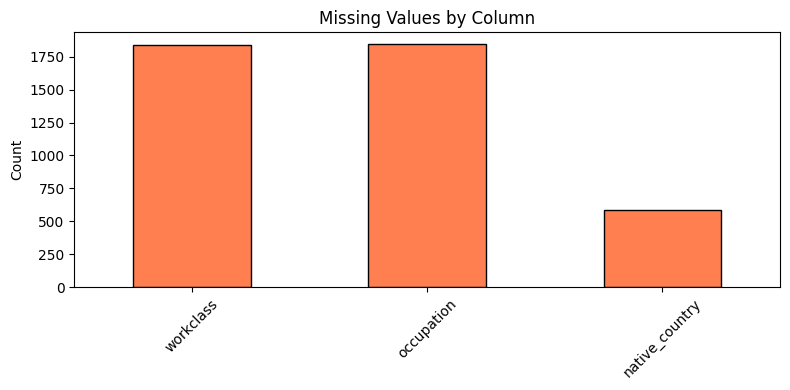

In [34]:
import matplotlib.pyplot as plt

# Bar chart of missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(8, 4))
missing.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Missing Values by Column')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.4 Strategies for Missing Data

| Strategy | When to Use | Code |
|----------|-------------|------|
| Drop rows | Few missing, random | `df.dropna()` |
| Drop columns | Many missing (>50%) | `df.drop(columns=['col'])` |
| Fill with mode | Categorical | `df['col'].fillna(df['col'].mode()[0])` |
| Fill with median | Numeric, skewed | `df['col'].fillna(df['col'].median())` |
| Fill with mean | Numeric, symmetric | `df['col'].fillna(df['col'].mean())` |

## 5.5 Applying Missing Value Strategies

In [35]:
# Option 1: Drop rows with missing values
df_dropped = df.dropna()
print(f"After dropping: {len(df_dropped)} rows (was {len(df)})")

After dropping: 30162 rows (was 32561)


In [36]:
# Option 2: Fill categorical with mode (most frequent)
df_filled = df.copy()
df_filled['workclass'] = df_filled['workclass'].fillna(
    df_filled['workclass'].mode()[0]
)
df_filled['occupation'] = df_filled['occupation'].fillna(
    df_filled['occupation'].mode()[0]
)
df_filled['native_country'] = df_filled['native_country'].fillna(
    df_filled['native_country'].mode()[0]
)

print(f"Missing after fill: {df_filled.isnull().sum().sum()}")

Missing after fill: 0



# Part VI: Exploring the Data

## 6.1 Target Variable Distribution

In [37]:
# What are we predicting?
print("Income counts:")
print(df['income'].value_counts())
print("\nIncome percentages:")
print(df['income'].value_counts(normalize=True).round(3))

Income counts:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Income percentages:
income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


**Key Insight:** Imbalanced classes! ~76% earn ≤50K. This affects model evaluation.

## 6.2 Numeric Feature Distributions

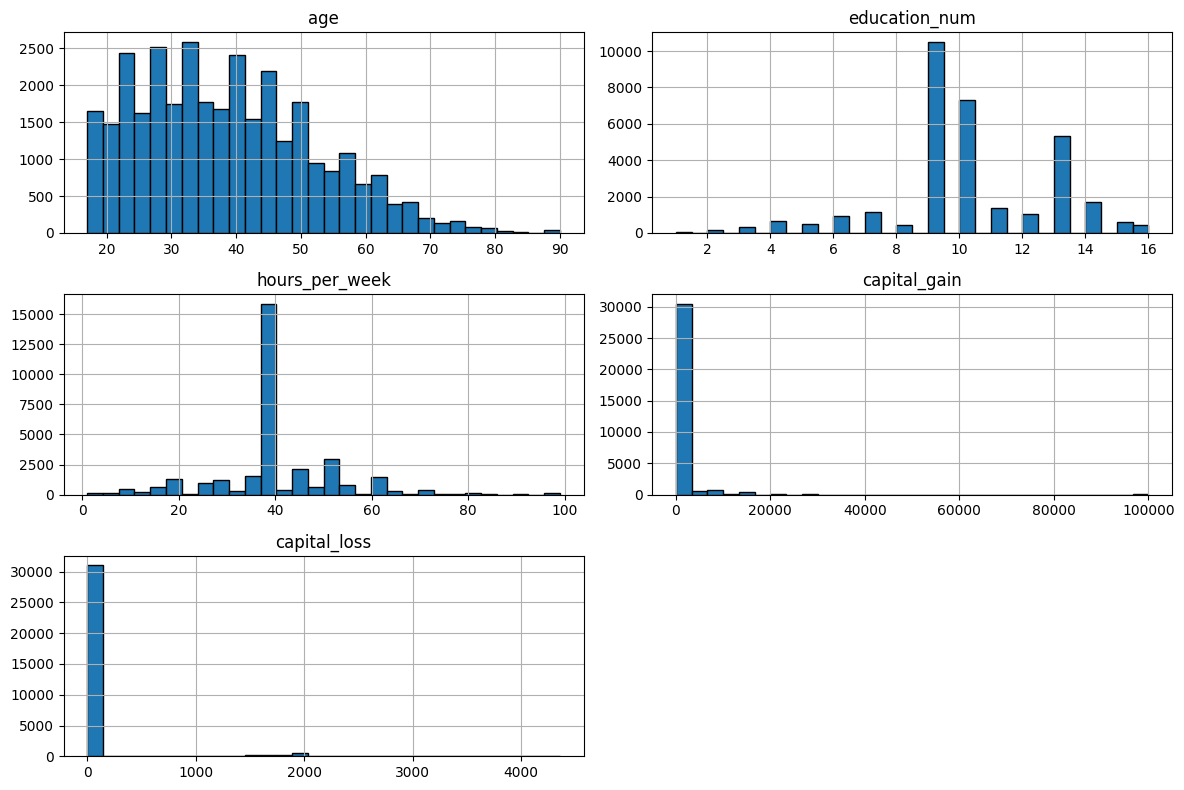

In [38]:
# Quick histograms for all numeric columns
numeric_cols = ['age', 'education_num', 'hours_per_week',
                'capital_gain', 'capital_loss']

df[numeric_cols].hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

## 6.3 Categorical Feature Distributions

In [39]:
# Education levels
print("Education value counts:")
print(df['education'].value_counts())

Education value counts:
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64


## 6.4 Relationship Between Features and Target

In [40]:
# Income by education level
income_by_edu = df.groupby('education')['income'].value_counts(normalize=True)
print(income_by_edu.unstack().round(3))

income        <=50K   >50K
education                 
10th          0.934  0.066
11th          0.949  0.051
12th          0.924  0.076
1st-4th       0.964  0.036
5th-6th       0.952  0.048
7th-8th       0.938  0.062
9th           0.947  0.053
Assoc-acdm    0.752  0.248
Assoc-voc     0.739  0.261
Bachelors     0.585  0.415
Doctorate     0.259  0.741
HS-grad       0.840  0.160
Masters       0.443  0.557
Preschool     1.000    NaN
Prof-school   0.266  0.734
Some-college  0.810  0.190


**Insight:** Higher education correlates with higher income (as expected).

## 6.5 Quick Crosstab Analysis

In [41]:
# Income by sex
print("Income distribution by sex:")
print(pd.crosstab(df['sex'], df['income'], normalize='index').round(3))

Income distribution by sex:
income  <=50K   >50K
sex                 
Female  0.891  0.109
Male    0.694  0.306


# Part VII: Basic Data Transformations

## 7.1 Creating New Features

In [42]:
# Binary flag: works more than 40 hours?
df['overtime'] = (df['hours_per_week'] > 40).astype(int)

# Age groups
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 25, 35, 50, 65, 100],
                         labels=['Young', 'Adult', 'Middle', 'Senior', 'Elder'])

print(df[['age', 'age_group', 'hours_per_week', 'overtime']].head(10))

   age age_group  hours_per_week  overtime
0   39    Middle              40         0
1   50    Middle              13         0
2   38    Middle              40         0
3   53    Senior              40         0
4   28     Adult              40         0
5   37    Middle              40         0
6   49    Middle              16         0
7   52    Senior              45         1
8   31     Adult              50         1
9   42    Middle              40         0


## 7.2 Binary Target Encoding

In [44]:
# Convert income to binary (0/1) for ML
df['income_binary'] = (df['income'] == '>50K').astype(int)

print("Binary income distribution:")
print(df['income_binary'].value_counts())

Binary income distribution:
income_binary
0    24720
1     7841
Name: count, dtype: int64


## 7.3 Selecting Features for ML

In [45]:
# Separate features and target
feature_cols = ['age', 'education_num', 'hours_per_week',
                'capital_gain', 'capital_loss']
X = df[feature_cols]
y = df['income_binary']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (32561, 5)
Target shape: (32561,)


# Summary

## NumPy Key Functions

| Function | Purpose | Example |
|----------|---------|--------|
| `np.array()` | Create array | `np.array([1,2,3])` |
| `np.mean()` | Average | `np.mean(arr)` |
| `np.std()` | Standard deviation | `np.std(arr)` |
| `arr[condition]` | Boolean filtering | `arr[arr > 0]` |

## Pandas Key Functions

| Function | Purpose | Example |
|----------|---------|--------|
| `pd.DataFrame()` | Create DataFrame | `pd.DataFrame(dict)` |
| `df.head()` | First n rows | `df.head(10)` |
| `df.describe()` | Statistics | `df.describe()` |
| `df[col]` | Select column | `df['age']` |
| `df[condition]` | Filter rows | `df[df['age'] > 30]` |
| `df[col].value_counts()` | Frequencies | `df['income'].value_counts()` |

## EDA Checklist

| Step | Command | What to Look For |
|------|---------|------------------|
| 1. Size | `df.shape` | How many rows/columns |
| 2. Preview | `df.head()` | What does the data look like |
| 3. Types | `df.dtypes` | Numeric vs categorical |
| 4. Missing | `df.isnull().sum()` | Which columns have gaps |
| 5. Stats | `df.describe()` | Ranges, means, outliers |
| 6. Target | `df['target'].value_counts()` | Class balance |
| 7. Relationships | `df.groupby()` | How features relate to target |

# Quick Reference


### Loading Data
```python
df = pd.read_csv('file.csv')                    # Basic load
df = pd.read_csv('file.csv', na_values='?')     # Handle missing
df.to_csv('output.csv', index=False)            # Save
```

### Inspection
```python
df.shape                    # (rows, cols)
df.head(10)                 # First 10 rows
df.info()                   # Types and missing
df.describe()               # Statistics
df['col'].value_counts()    # Frequency table
```

### Missing Values
```python
df.isnull().sum()                    # Count missing
df.dropna()                          # Drop rows with missing
df['col'].fillna(value)              # Fill missing
```

### Filtering
```python
df[df['age'] > 40]                             # Filter rows
df[(df['age'] > 40) & (df['income'] == '>50K')]  # Multiple conditions
```

---

*Week 2, Lecture 1 — CS 2100/4700: Introduction to Machine Learning*